# Sample-interception diagnostics: a 10 × 10 mm square

This notebook evaluates the implemented joint beam/sample overlap using
`orgui.datautils.xrayutils.corrections.sample_interception.overlap`.
All plots are synthetic, reproducible diagnostics with normalized independent
vertical and horizontal beam profiles. No scan file or GUI is needed.

Run all cells to compare vertical beam families, horizontal profiles and
horizontal width for **μ scans** and **th scans**. Editable parameters are grouped
below. Saved outputs make the plots available without running the calculations.
The default grids take a few minutes on a typical workstation.

## What is being plotted?

For incidence $\alpha$ and geometric surface-normal rotation $\psi$,

$$H(\alpha,\psi)=\int_{S(\psi)}
p_z(z_{\rm axis}+x\sin\alpha)\,p_h(y_{\rm axis}+y)\,dx\,dy,
\qquad f_{\rm hit}=\sin\alpha\,H.$$

* **H** is the dimensionless total-flux illumination divisor: a fluence-normalized
  signal is divided by H. **1/H** is the corresponding applied multiplier.
* **$f_{\rm hit}$** is intercepted incident flux, between zero and one.
* The legacy peak-density convention uses
  $A_{\rm eff}=H/(p_{z,\max}p_{h,\max})$ and
  $C_{\rm area}=A_{\rm eff}/A_{\rm sample}$; its multiplier is $1/C_{\rm area}$.

The notebook isolates illumination. Exposure/monitor normalization, angular
factors, polarization and detector corrections are outside these plots.

## Scan and alignment conventions

Here **μ is identified with physical incidence α** and **th is explicitly
declared to rotate about the surface normal**. For a μ scan, α changes while th
stays fixed. For a th scan, μ = 0.36° stays fixed and
$\psi=s(\mathrm{th}-\mathrm{th}_{\rm ref})$ changes. The sign $s$ is editable.
This is a declared synthetic geometry; a motor name alone does not establish
that geometry on a real instrument. In particular, these th values are source
readbacks, not calculated six-circle peak angles or the application's omega.

The square is centred on the rotation axis by default. If the offset is changed,
it rotates with the sample; profile alignment is fixed in laboratory coordinates
at the declared reference incidence/azimuth. Shape coordinates use metres and
the numerical kernel takes radians. Plot axes use degrees, mm or μm as labelled.
The surface x direction is along the projected incident beam, and positive ψ is
right-handed about the surface normal (x cross y).

In [1]:
%matplotlib inline
from pathlib import Path
import sys
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.special import erf

# Find a checkout when launched from the repository or doc/source directory.
repo = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "orgui/datautils/xrayutils/corrections/sample_interception.py").is_file()), None)
if repo is not None and str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from orgui.datautils.xrayutils.corrections import beamprofile as bp
from orgui.datautils.xrayutils.corrections.sample_interception import SampleShape, overlap

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.22, "axes.spines.top": False,
    "axes.spines.right": False, "savefig.bbox": "tight",
})

In [2]:
# Editable physical parameters: UI-friendly units here, converted once below.
SQUARE_SIDE_MM = 10.0
VERTICAL_FWHM_UM = 160.0
MU_FIXED_DEG = 0.36
REFERENCE_MU_DEG = 0.36
TH_REFERENCE_DEG = 0.0
TH_SIGN = +1                  # Declared readback -> geometric rotation sign.
SHAPE_ORIENTATION_DEG = 0.0  # Orientation at the reference th readback.
OFFSET_MM = (0.0, 0.0)       # Sample-fixed displacement from the rotation axis.
MU_SCAN_TH_DEG = (0.0, 45.0)
MU_POINTS = 37
TH_POINTS = 49
RTOL = 1e-8

mu_deg = np.geomspace(0.02, 2.0, MU_POINTS)  # Positive incidence only.
th_deg = np.linspace(-90.0, 90.0, TH_POINTS)
sample = SampleShape("rectangle", (SQUARE_SIDE_MM * 1e-3,) * 2)
offset_m = np.asarray(OFFSET_MM) * 1e-3
orientation_rad = np.deg2rad(SHAPE_ORIENTATION_DEG)
axis_vertical_m = -offset_m[0] * np.sin(np.deg2rad(REFERENCE_MU_DEG))
axis_horizontal_m = -offset_m[1]
assert TH_SIGN in (-1, +1)

display(pd.DataFrame([
    {"parameter": "Square side", "value": SQUARE_SIDE_MM, "unit": "mm"},
    {"parameter": "Vertical reference FWHM", "value": VERTICAL_FWHM_UM, "unit": "μm"},
    {"parameter": "th-scan incidence", "value": MU_FIXED_DEG, "unit": "deg"},
    {"parameter": "μ range", "value": f"{mu_deg[0]:g}–{mu_deg[-1]:g}", "unit": "deg"},
    {"parameter": "th range", "value": f"{th_deg[0]:g}–{th_deg[-1]:g}", "unit": "deg"},
    {"parameter": "Offset (sample x, y)", "value": str(OFFSET_MM), "unit": "mm"},
]))

,parameter,value,unit
0,Square side,10.0,mm
1,Vertical reference FWHM,160.0,μm
2,th-scan incidence,0.36,deg
3,μ range,0.02–2,deg
4,th range,-90–90,deg
5,"Offset (sample x, y)","(0.0, 0.0)",mm


## Beam families and normalization

The vertical analytical families have a nominal 160 μm FWHM. A triangle's full
support is twice its FWHM; the trapezoid uses a 240 μm base and an 80 μm plateau.
The smoothed top hat starts with a 160 μm slit width and a 20 μm edge sigma;
its resulting FWHM is reported in the table. Generalized normal uses exponent 4,
and skew normal uses skew 4 and centroid centring.

The **synthetic measured profile** is a piecewise-linear Gaussian mixture with
a shoulder. It is rescaled to the reference FWHM and centred on its centroid.
It exercises the same measured-density API as imported beam data. Its finite
table has zero exterior density. It is synthetic, not an instrument measurement.
All profiles are individually normalized to unit integral; changing the family
can change peak density even at the same FWHM.

The horizontal comparisons deliberately include both family and width changes;
their physical widths are explicit in every legend. This shows how transverse
clipping affects the result separately from the vertical-family comparison.

,vertical profile,FWHM [μm],peak density [μm⁻¹],total interval mass
0,Gaussian,160.000030,0.005871,1.0
1,Top hat,159.999680,0.006250,1.0
2,Triangle,160.000000,0.006250,1.0
3,Trapezoid,160.000000,0.006250,1.0
4,Smoothed top hat,160.003176,0.006250,1.0
5,Generalized normal (β=4),159.999997,0.006292,1.0
6,Skew normal (skew=4),159.999882,0.005779,1.0
7,Synthetic measured,160.000000,0.005577,1.0


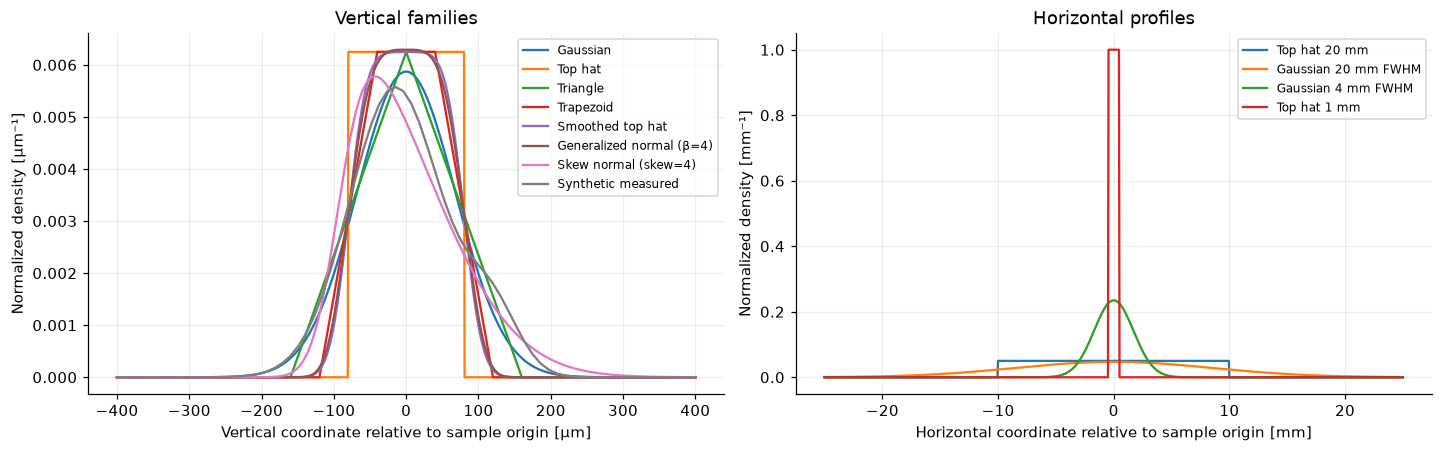

In [3]:
width = VERTICAL_FWHM_UM * 1e-6
vertical_profiles = {
    "Gaussian": bp.gaussian_profile(width),
    "Top hat": bp.top_hat_profile(width),
    "Triangle": bp.triangular_profile(2 * width),
    "Trapezoid": bp.trapezoid_profile(1.5 * width, 0.5 * width),
    "Smoothed top hat": bp.smoothed_top_hat_profile(width, width / 8),
    "Generalized normal (β=4)": bp.generalized_normal_profile(width, 4),
    "Skew normal (skew=4)": bp.skew_normal_profile(width, 4),
}
z_table = np.linspace(-4 * width, 4 * width, 121)
raw_density = (0.82 * np.exp(-0.5 * (z_table / (0.38 * width))**2)
               + 0.18 * np.exp(-0.5 * ((z_table - 0.8 * width) / (0.22 * width))**2))
trial = bp.MeasuredBeamProfile(z_table, raw_density, center="centroid")
vertical_profiles["Synthetic measured"] = bp.MeasuredBeamProfile(
    z_table * width / trial.fwhm, raw_density, center="centroid"
)

horizontal_profiles = {
    "Top hat 20 mm": bp.top_hat_profile(20e-3),
    "Gaussian 20 mm FWHM": bp.gaussian_profile(20e-3),
    "Gaussian 4 mm FWHM": bp.gaussian_profile(4e-3),
    "Top hat 1 mm": bp.top_hat_profile(1e-3),
}
baseline_horizontal = horizontal_profiles["Top hat 20 mm"]
baseline_vertical = vertical_profiles["Gaussian"]
vertical_colors = dict(zip(vertical_profiles, plt.get_cmap("tab10").colors))

profile_table = pd.DataFrame([
    {"vertical profile": name, "FWHM [μm]": profile.fwhm * 1e6,
     "peak density [μm⁻¹]": profile.peak_density * 1e-6,
     "total interval mass": float(profile.interval_mass(-np.inf, np.inf))}
    for name, profile in vertical_profiles.items()
])
display(profile_table.round(6))
assert np.allclose(profile_table["total interval mass"], 1.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
z = np.linspace(-2.5 * width, 2.5 * width, 1001)
for name, profile in vertical_profiles.items():
    axes[0].plot(z * 1e6, profile.density_at(z) * 1e-6,
                 label=name, color=vertical_colors[name])
y = np.linspace(-25e-3, 25e-3, 1001)
for name, profile in horizontal_profiles.items():
    axes[1].plot(y * 1e3, profile.density_at(y) * 1e-3, label=name)
axes[0].set(xlabel="Vertical coordinate relative to sample origin [μm]",
            ylabel="Normalized density [μm⁻¹]", title="Vertical families")
axes[1].set(xlabel="Horizontal coordinate relative to sample origin [mm]",
            ylabel="Normalized density [mm⁻¹]", title="Horizontal profiles")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.show()

In [4]:
def evaluate(vertical, horizontal, mu_values_deg, th_values_deg):
    '''Return exact shape overlap; inputs are degrees, alignment is fixed SI.'''
    psi = TH_SIGN * np.deg2rad(np.asarray(th_values_deg) - TH_REFERENCE_DEG)
    return overlap(
        sample, vertical, horizontal, np.deg2rad(mu_values_deg), psi,
        offset=offset_m, orientation=orientation_rad,
        axis_vertical=axis_vertical_m, axis_horizontal=axis_horizontal_m,
        rtol=RTOL,
    )


def diagnostics(result):
    '''Return dimensionless H, f_hit, applied multipliers and legacy area.'''
    area_fraction = result.effective_area / sample.area
    return {
        "H": result.illumination,
        "f_hit": result.fraction,
        "1/H": np.divide(1., result.illumination,
                         out=np.full_like(result.illumination, np.nan),
                         where=result.illumination > 0),
        "C_area": area_fraction,
        "1/C_area": np.divide(1., area_fraction,
                              out=np.full_like(area_fraction, np.nan),
                              where=area_fraction > 0),
    }


mu_results, th_results, timing_rows = {}, {}, []

## Vertical families: μ scans at edge and diagonal orientations

The horizontal profile is fixed to the normalized **20 mm top hat**. Each μ
scan changes physical incidence while keeping the indicated th readback fixed.
The beam width is comparable to the projected sample height near the default
0.36° incidence. The left panels show H; the middle panels show flux intercepted;
the right panels show the multiplier actually applied on a total-flux scale.
The μ axis is logarithmic to resolve the positive grazing-incidence region.

In [5]:
for name, vertical in vertical_profiles.items():
    start = perf_counter()
    for angle in MU_SCAN_TH_DEG:
        mu_results[name, angle] = evaluate(vertical, baseline_horizontal, mu_deg, angle)
    th_results[name] = evaluate(vertical, baseline_horizontal, MU_FIXED_DEG, th_deg)
    timing_rows.append({"case": f"Vertical: {name}", "seconds": perf_counter() - start})
    print(f"{name}: μ and th scans calculated")

Gaussian: μ and th scans calculated


Top hat: μ and th scans calculated


Triangle: μ and th scans calculated


Trapezoid: μ and th scans calculated


Smoothed top hat: μ and th scans calculated


Generalized normal (β=4): μ and th scans calculated


Skew normal (skew=4): μ and th scans calculated


Synthetic measured: μ and th scans calculated


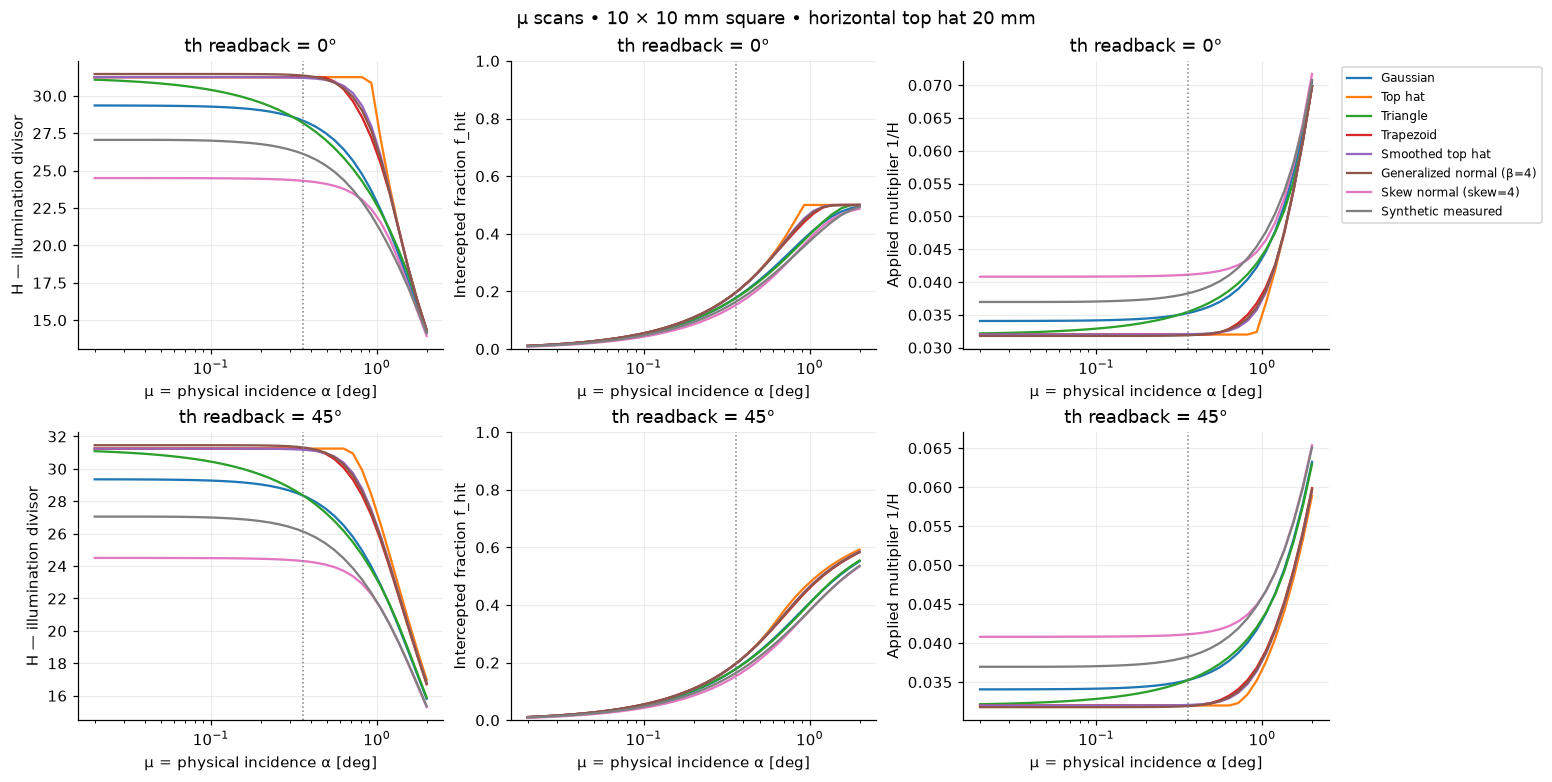

In [6]:
fig, axes = plt.subplots(len(MU_SCAN_TH_DEG), 3, figsize=(14, 7),
                         squeeze=False, layout="constrained")
labels = {"H": "H — illumination divisor", "f_hit": "Intercepted fraction f_hit",
          "1/H": "Applied multiplier 1/H"}
for row, angle in enumerate(MU_SCAN_TH_DEG):
    for name in vertical_profiles:
        values = diagnostics(mu_results[name, angle])
        for column, key in enumerate(labels):
            axes[row, column].semilogx(mu_deg, values[key], label=name,
                                       color=vertical_colors[name])
    for column, key in enumerate(labels):
        axes[row, column].set(xlabel="μ = physical incidence α [deg]",
                              ylabel=labels[key], title=f"th readback = {angle:g}°")
        axes[row, column].axvline(MU_FIXED_DEG, color="0.5", ls=":", lw=1)
axes[0, 1].set_ylim(0, 1)
axes[-1, 1].set_ylim(0, 1)
axes[0, -1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle(f"μ scans • {SQUARE_SIDE_MM:g} × {SQUARE_SIDE_MM:g} mm square • horizontal top hat 20 mm")
plt.show()

## Vertical families: th scans at fixed μ

These scans vary the declared normal rotation at μ = 0.36°. The relative-H panel
resolves the small modulation that a wide horizontal beam can produce. Its
reference is the same profile at the declared reference th readback. The
centred square has 90° rotational periodicity. Peak-density area normalization
is included explicitly in the final panel; it gives a different multiplier
from the total-flux convention.

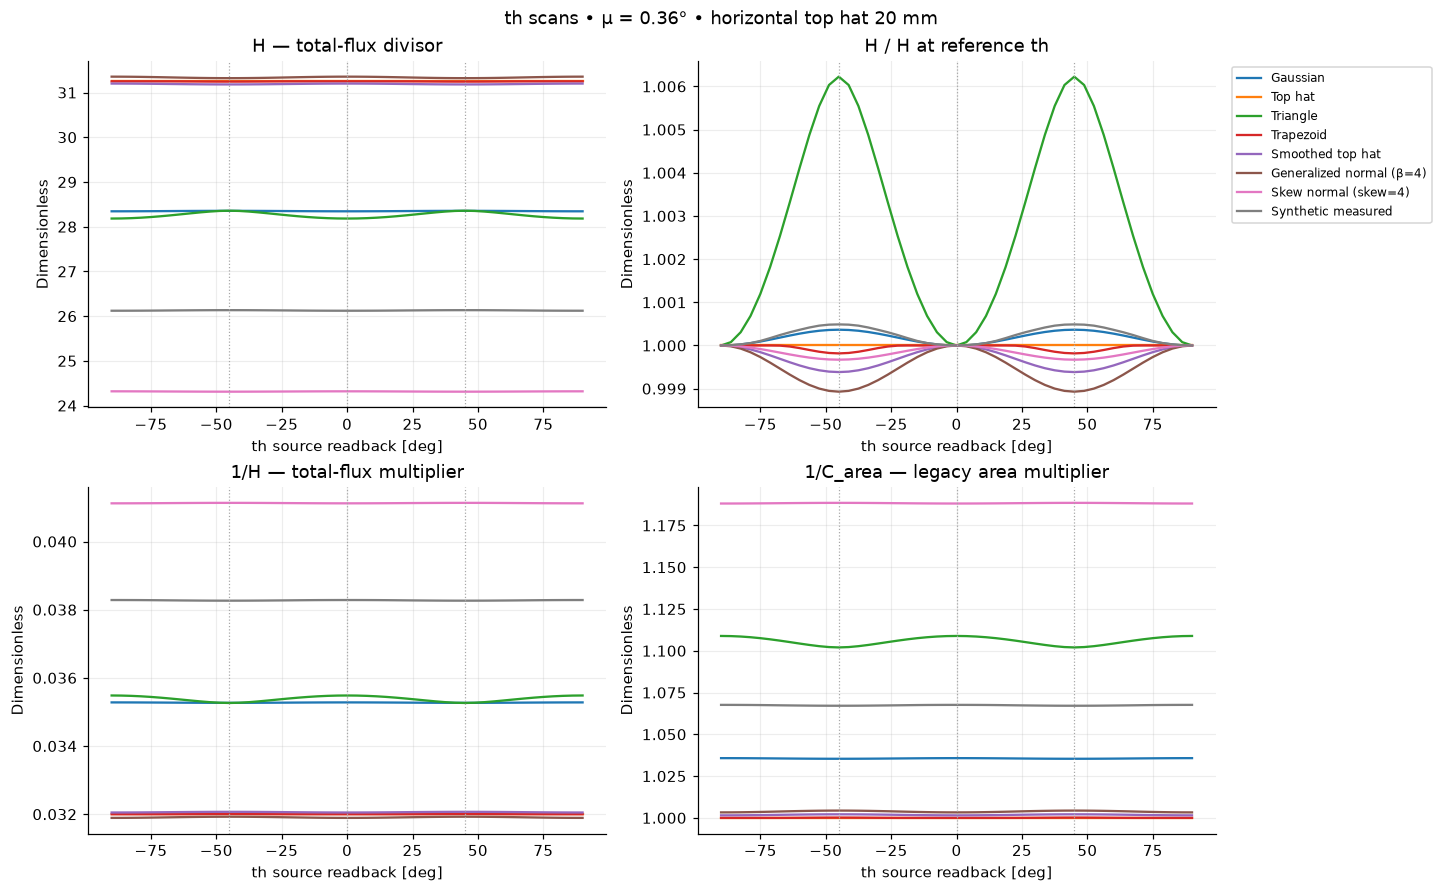

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")
for name, profile in vertical_profiles.items():
    values = diagnostics(th_results[name])
    reference = evaluate(profile, baseline_horizontal, MU_FIXED_DEG, TH_REFERENCE_DEG)
    for ax, key in zip([axes[0, 0], axes[1, 0], axes[1, 1]], ["H", "1/H", "1/C_area"]):
        ax.plot(th_deg, values[key], label=name, color=vertical_colors[name])
    axes[0, 1].plot(th_deg, values["H"] / reference.illumination,
                    color=vertical_colors[name], label=name)
for ax, title in zip(axes.flat, ["H — total-flux divisor", "H / H at reference th",
                                "1/H — total-flux multiplier", "1/C_area — legacy area multiplier"]):
    ax.set(xlabel="th source readback [deg]", ylabel="Dimensionless", title=title)
    for angle in (-45, 0, 45):
        ax.axvline(angle, color="0.65", ls=":", lw=0.8)
axes[0, 1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle(f"th scans • μ = {MU_FIXED_DEG:g}° • horizontal top hat 20 mm")
plt.show()

## Horizontal family and width: μ and th scans

The vertical profile is now fixed to the **160 μm FWHM Gaussian**. Wide and
narrow horizontal profiles expose transverse clipping of the rotated square.
For narrow illumination, the sample's available chord along the beam grows
towards the diagonal, whereas the wide-beam overlap depends on the entire
illuminated surface. Both vertical and horizontal profiles are normalized;
the total incident beam flux is held fixed conceptually in this comparison.

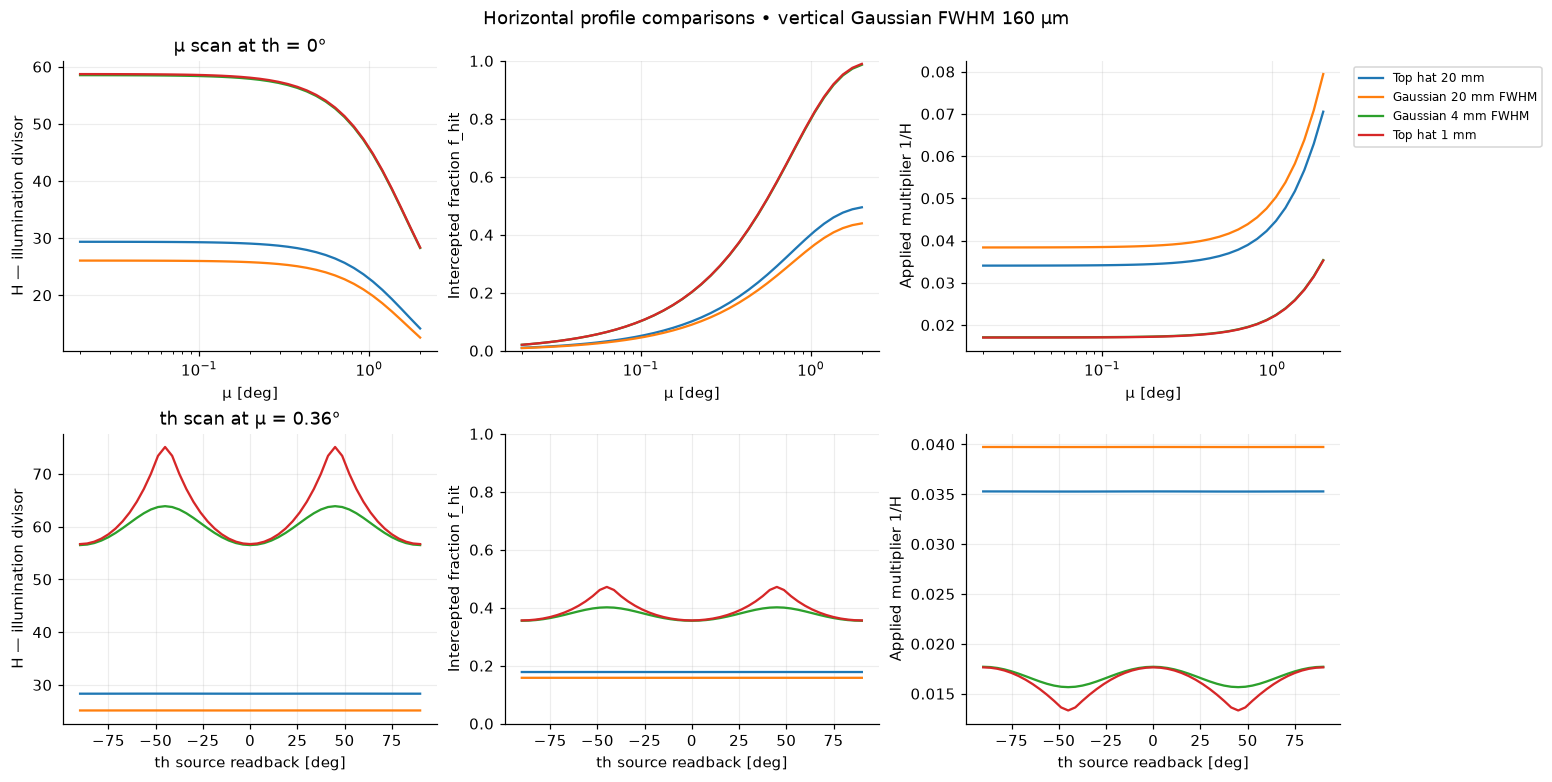

In [8]:
horizontal_mu, horizontal_th = {}, {}
for name, horizontal in horizontal_profiles.items():
    start = perf_counter()
    if name == "Top hat 20 mm":
        horizontal_mu[name] = mu_results["Gaussian", MU_SCAN_TH_DEG[0]]
        horizontal_th[name] = th_results["Gaussian"]
    else:
        horizontal_mu[name] = evaluate(baseline_vertical, horizontal, mu_deg, MU_SCAN_TH_DEG[0])
        horizontal_th[name] = evaluate(baseline_vertical, horizontal, MU_FIXED_DEG, th_deg)
    timing_rows.append({"case": f"Horizontal: {name}", "seconds": perf_counter() - start})

fig, axes = plt.subplots(2, 3, figsize=(14, 7), layout="constrained")
for name in horizontal_profiles:
    for row, results, x in [(0, horizontal_mu, mu_deg), (1, horizontal_th, th_deg)]:
        values = diagnostics(results[name])
        for column, key in enumerate(labels):
            axes[row, column].plot(x, values[key], label=name)
for row in range(2):
    for column, key in enumerate(labels):
        axes[row, column].set(xlabel="μ [deg]" if row == 0 else "th source readback [deg]",
                              ylabel=labels[key])
        if row == 0:
            axes[row, column].set_xscale("log")
    axes[row, 1].set_ylim(0, 1)
axes[0, 0].set_title(f"μ scan at th = {MU_SCAN_TH_DEG[0]:g}°")
axes[1, 0].set_title(f"th scan at μ = {MU_FIXED_DEG:g}°")
axes[0, -1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle(f"Horizontal profile comparisons • vertical Gaussian FWHM {VERTICAL_FWHM_UM:g} μm")
plt.show()

## Why a rotated square cannot be replaced by its bounding rectangle

This diagnostic compares the true joint overlap with the integral over the
square's axis-aligned bounding rectangle. The enclosing rectangle includes
surface that does not belong to the square; its product of interval masses is
therefore only an enclosing-area approximation. Both calculations use the
same normalized beam profiles and alignment. The discrepancy plot reports
the overestimate of H, which would underestimate corrected intensity.

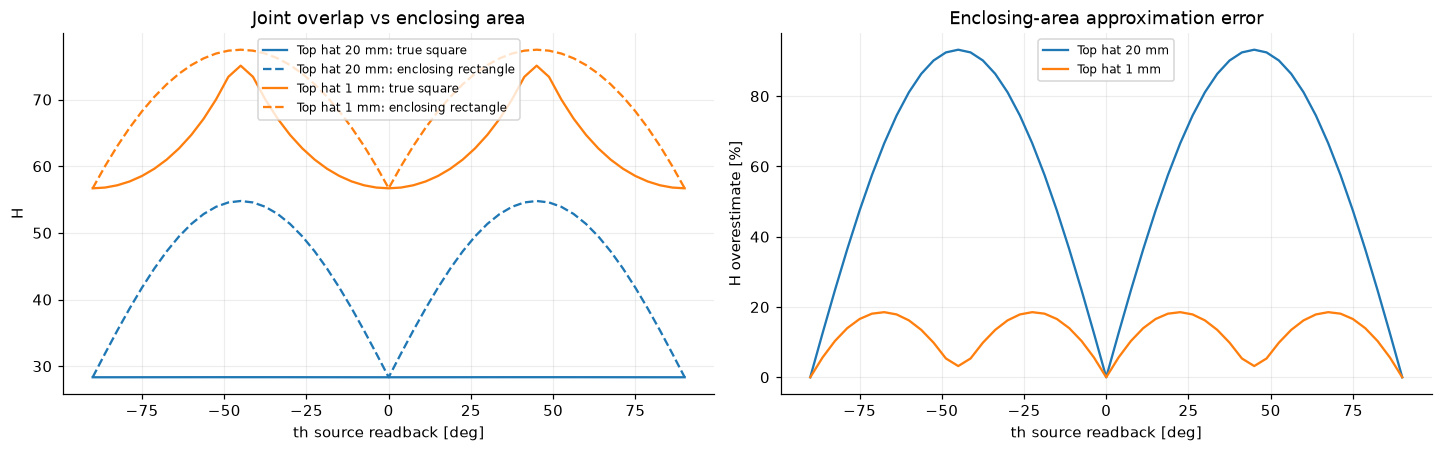

In [9]:
bounding_results = {}
for name in ("Top hat 20 mm", "Top hat 1 mm"):
    horizontal = horizontal_profiles[name]
    bbox_h = []
    for theta in th_deg:
        psi = TH_SIGN * np.deg2rad(theta - TH_REFERENCE_DEG)
        vertices = sample.outline(psi, offset_m, orientation_rad)
        low, high = vertices.min(axis=0), vertices.max(axis=0)
        sine = np.sin(np.deg2rad(MU_FIXED_DEG))
        fz = baseline_vertical.interval_mass(axis_vertical_m + low[0] * sine,
                                             axis_vertical_m + high[0] * sine)
        fh = horizontal.interval_mass(axis_horizontal_m + low[1], axis_horizontal_m + high[1])
        bbox_h.append(float(fz * fh / sine))
    bounding_results[name] = np.asarray(bbox_h)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for name in bounding_results:
    actual = horizontal_th[name].illumination
    line, = axes[0].plot(th_deg, actual, label=f"{name}: true square")
    axes[0].plot(th_deg, bounding_results[name], ls="--", color=line.get_color(),
                 label=f"{name}: enclosing rectangle")
    axes[1].plot(th_deg, 100 * (bounding_results[name] / actual - 1), label=name)
axes[0].set(xlabel="th source readback [deg]", ylabel="H", title="Joint overlap vs enclosing area")
axes[1].set(xlabel="th source readback [deg]", ylabel="H overestimate [%]", title="Enclosing-area approximation error")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.show()

## Footprint geometry at edge and diagonal orientations

The image shows incident surface density relative to its peak. The square
outline has the same physical scale in x and y. The density image includes
beam falling outside the square, so overspill is visible. The rotation axis
is marked by a cross. Each panel reports the actual intercepted fraction.

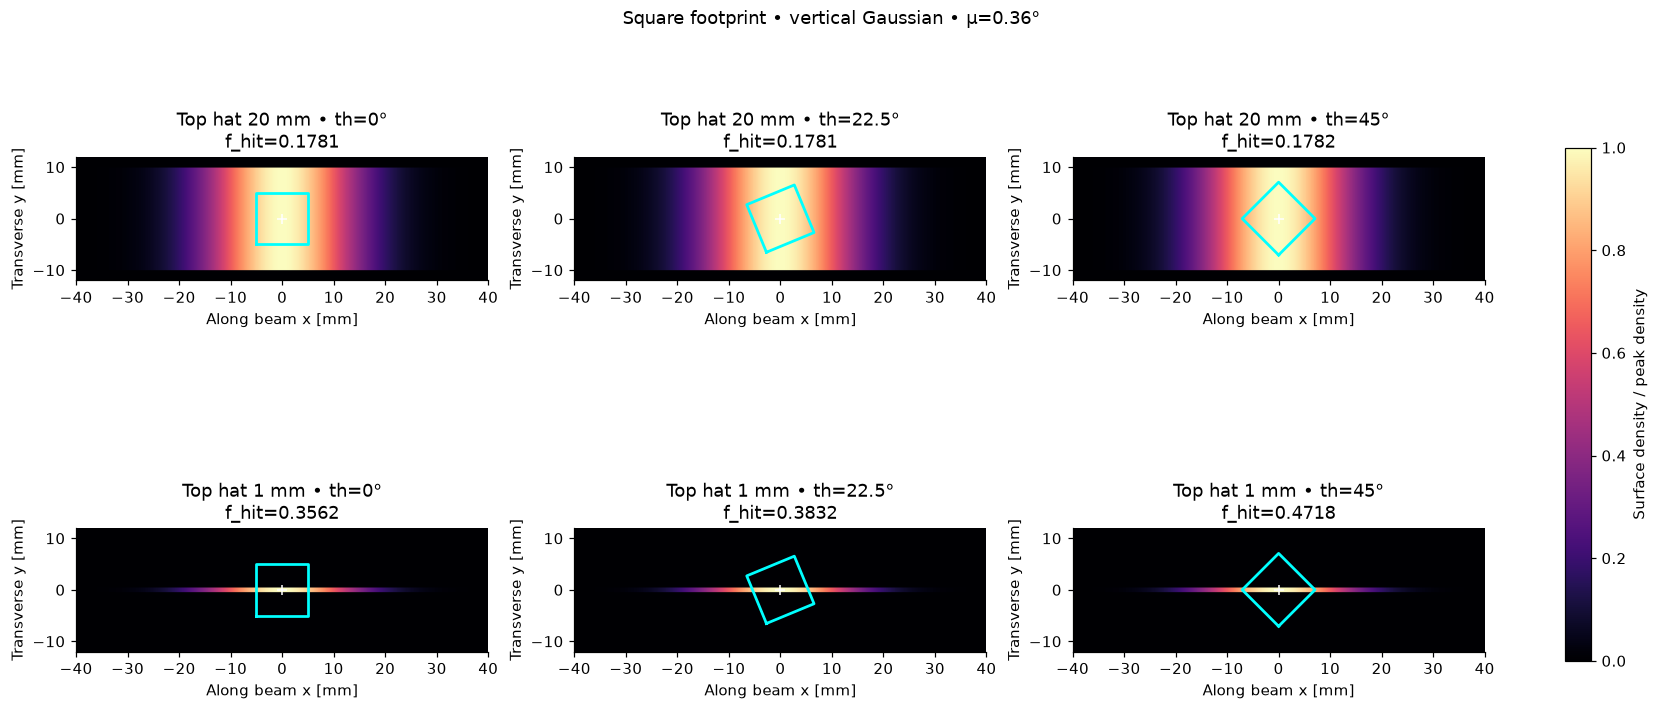

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), layout="constrained")
x = np.linspace(-40e-3, 40e-3, 401)
y = np.linspace(-12e-3, 12e-3, 241)
for row, horizontal_name in enumerate(("Top hat 20 mm", "Top hat 1 mm")):
    horizontal = horizontal_profiles[horizontal_name]
    density = (baseline_vertical.density_at(axis_vertical_m + x[None, :] * np.sin(np.deg2rad(MU_FIXED_DEG)))
               * horizontal.density_at(axis_horizontal_m + y[:, None]))
    density /= baseline_vertical.peak_density * horizontal.peak_density
    for column, theta in enumerate((0.0, 22.5, 45.0)):
        ax = axes[row, column]
        image = ax.imshow(density, extent=[x[0] * 1e3, x[-1] * 1e3, y[0] * 1e3, y[-1] * 1e3],
                          origin="lower", aspect="equal", cmap="magma", vmin=0, vmax=1)
        psi = TH_SIGN * np.deg2rad(theta - TH_REFERENCE_DEG)
        outline = sample.outline(psi, offset_m, orientation_rad) * 1e3
        closed = np.vstack((outline, outline[0]))
        ax.plot(closed[:, 0], closed[:, 1], color="cyan", lw=1.8)
        ax.plot(0, 0, "+", color="white", ms=7)
        actual = evaluate(baseline_vertical, horizontal, MU_FIXED_DEG, theta)
        ax.set(xlabel="Along beam x [mm]", ylabel="Transverse y [mm]",
                title=f"{horizontal_name} • th={theta:g}°\nf_hit={float(actual.fraction):.4f}")
        ax.grid(False)
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.7, label="Surface density / peak density")
fig.suptitle(f"Square footprint • vertical Gaussian • μ={MU_FIXED_DEG:g}°")
plt.show()

## Independent numerical checks and application sanity check

The following reference checks always use the specified **10 mm square**,
**0.36° incidence**, and **160 μm Gaussian**, independently of edits above.
The edge-orientation reference is an error-function interval integral times
the horizontal top-hat mass. The narrow-beam diagonal limit uses the central
diagonal chord. The wide-beam diagonal reference is the value established
by the independent validation of the correction implementation.

The application plot then uses a constant intrinsic signal of 1 and the narrow
horizontal top hat. Its fluence-normalized observed signal is H; applying 1/H
recovers 1 pointwise in both scan modes. Replacing H by the enclosing rectangle
leaves a shape-dependent residual in the th scan.

In [11]:
reference_sample = SampleShape("rectangle", (0.01, 0.01))
reference_vertical = bp.gaussian_profile(160e-6)
reference_alpha = np.deg2rad(0.36)
sigma = 160e-6 / np.sqrt(8 * np.log(2))
wide = overlap(reference_sample, reference_vertical, bp.top_hat_profile(.02),
               reference_alpha, [0, np.pi / 4])
narrow = overlap(reference_sample, reference_vertical, bp.top_hat_profile(1e-7),
                 reference_alpha, [0, np.pi / 4])
edge_fraction = erf(.005 * np.sin(reference_alpha) / (np.sqrt(2) * sigma))
diagonal_limit = erf(.005 * np.sqrt(2) * np.sin(reference_alpha) / (np.sqrt(2) * sigma))
np.testing.assert_allclose(wide.fraction, [.178090128539, .178155252900], atol=1e-11)
np.testing.assert_allclose(narrow.fraction, [edge_fraction, diagonal_limit], rtol=2e-5)

periodic = overlap(reference_sample, reference_vertical, bp.top_hat_profile(.001),
                   reference_alpha, np.deg2rad([13, 103]))
np.testing.assert_allclose(periodic.fraction[0], periodic.fraction[1], rtol=1e-10)
grazing = overlap(reference_sample, reference_vertical, bp.top_hat_profile(.02), 1e-20, 0)
expected_grazing_h = .01 * reference_vertical.density_at(0) * .5
np.testing.assert_allclose(grazing.illumination, expected_grazing_h, rtol=1e-9)

display(pd.DataFrame({
    "reference case": ["20 mm top hat, edge", "20 mm top hat, diagonal",
                       "Narrow central beam, edge", "Narrow central beam, diagonal"],
    "computed f_hit": [*wide.fraction, *narrow.fraction],
    "reference / limit": [.178090128539, .178155252900, edge_fraction, diagonal_limit],
}))

all_results = [*mu_results.values(), *th_results.values(),
               *horizontal_mu.values(), *horizontal_th.values()]
for result in all_results:
    assert np.all(np.isfinite(result.illumination))
    assert np.all(result.illumination > 0)
    assert np.all((result.fraction >= 0) & (result.fraction <= 1 + 1e-10))
    assert np.all(result.effective_area <= sample.area * (1 + 1e-9))
print("Reference, probability, symmetry, grazing and effective-area checks passed.")

,reference case,computed f_hit,reference / limit
0,"20 mm top hat, edge",0.178090,0.178090
1,"20 mm top hat, diagonal",0.178155,0.178155
2,"Narrow central beam, edge",0.356180,0.356180
3,"Narrow central beam, diagonal",0.486811,0.486813


Reference, probability, symmetry, grazing and effective-area checks passed.


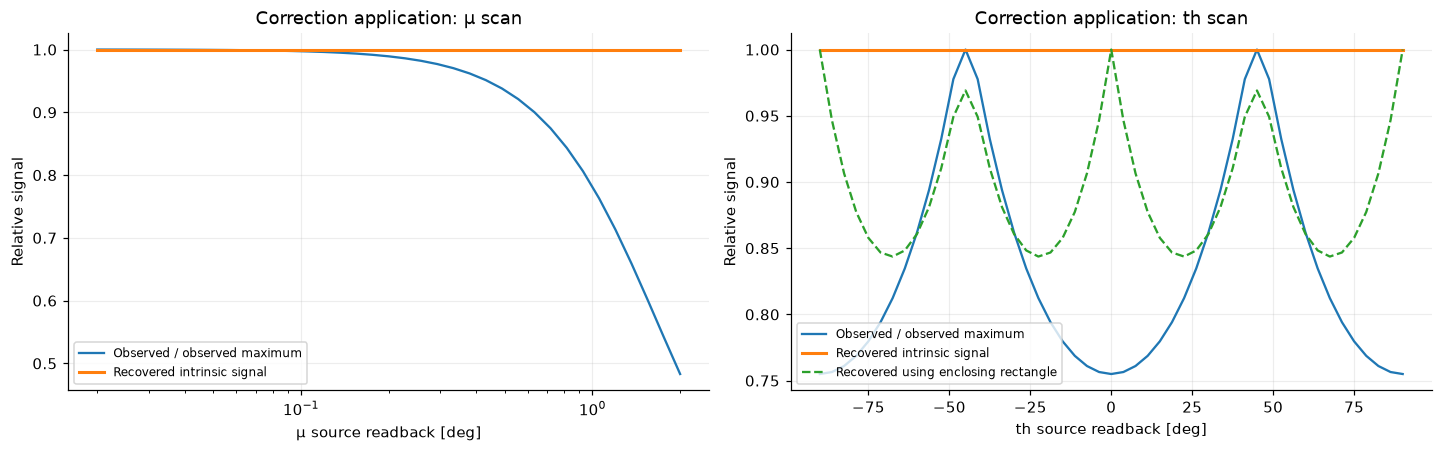

,vertical profile,max estimated H quadrature error,minimum f_hit in th scan,maximum f_hit in th scan
0,Gaussian,3.147979e-13,0.178090,0.178155
1,Top hat,3.469447e-13,0.196348,0.196348
2,Triangle,3.148317e-13,0.177072,0.178174
3,Trapezoid,3.469447e-13,0.196312,0.196348
4,Smoothed top hat,3.463947e-13,0.195916,0.196037
5,Generalized normal (β=4),3.481112e-13,0.196798,0.197008
6,Skew normal (skew=4),2.699912e-13,0.152747,0.152798
7,Synthetic measured,2.901392e-13,0.164120,0.164200


,case,seconds
0,Vertical: Gaussian,5.048
1,Vertical: Top hat,5.840
2,Vertical: Triangle,7.281
3,Vertical: Trapezoid,8.016
4,Vertical: Smoothed top hat,5.146
5,Vertical: Generalized normal (β=4),5.892
6,Vertical: Skew normal (skew=4),6.011
7,Vertical: Synthetic measured,7.972
8,Horizontal: Top hat 20 mm,0.000
9,Horizontal: Gaussian 20 mm FWHM,1.596


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for ax, x_values, result, mode in [
    (axes[0], mu_deg, horizontal_mu["Top hat 1 mm"], "μ"),
    (axes[1], th_deg, horizontal_th["Top hat 1 mm"], "th"),
]:
    observed = result.illumination  # Q-normalized raw signal; intrinsic value = 1.
    corrected = observed * diagnostics(result)["1/H"]
    np.testing.assert_allclose(corrected, 1, rtol=1e-12)
    ax.plot(x_values, observed / observed.max(), label="Observed / observed maximum")
    ax.plot(x_values, corrected, label="Recovered intrinsic signal", lw=2)
    if mode == "th":
        ax.plot(x_values, observed / bounding_results["Top hat 1 mm"], ls="--",
                 label="Recovered using enclosing rectangle")
    else:
        ax.set_xscale("log")
    ax.set(xlabel=f"{mode} source readback [deg]", ylabel="Relative signal",
            title=f"Correction application: {mode} scan")
    ax.legend(fontsize=8)
plt.show()

error_summary = pd.DataFrame([
    {"vertical profile": name,
     "max estimated H quadrature error": float(np.max(result.error)),
     "minimum f_hit in th scan": float(np.min(result.fraction)),
     "maximum f_hit in th scan": float(np.max(result.fraction))}
    for name, result in th_results.items()
])
display(error_summary)
display(pd.DataFrame(timing_rows).round(3))

## Using these diagnostics for a measurement

Edit the parameter cell and rerun all cells. Change widths, family parameters,
centering/offsets and the source-readback sign/reference to match the instrument.
The results are retained in `mu_results`, `th_results`, `horizontal_mu` and
`horizontal_th`; `diagnostics(result)` provides all plotted divisors/multipliers.
To export a plot, call `fig.savefig("chosen_name.png", dpi=180)` in its plot cell.

For actual measured profiles, replace the synthetic profile with
`bp.MeasuredBeamProfile(positions_m, density, center="centroid", offset=offset_m)`.
Positions and offsets at that boundary are metres. The density may start on an
arbitrary nonnegative scale and is normalized by the constructor. Validate its
support, centring and background subtraction before using it as a probability
profile. The horizontal profile is required for the joint correction.

The quoted numerical errors concern quadrature only. Profile measurement error,
sample placement, beam drift and angular uncertainty are not included. The model
assumes a flat sample, independent separable beam densities and representative
angles per exposure. It does not infer unrecorded stage translations or integrate
motion within an exposure. Invalid incidence and zero overlap need explicit
frame-exclusion handling in the application; the default diagnostic grids contain
positive incidence and nonzero overlap throughout.